In [7]:
import scanpy as sc
import pandas as pd

In [2]:
pwd

'/media/AnalysisTempDisk/Caipengfei/workspace/cxy/public'

In [8]:
import pandas as pd

# 读取原始 features.tsv.gz
features = pd.read_csv("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/data/public/features.tsv.gz", header=None, sep="\t")

# 假设原本只有一列，现在加一列（比如 gene_id 和 gene_symbol 都一样）
features[1] = features[0]  # 新增第二列，内容与第一列相同
features[2] = "Gene Expression"
# 保存为新的 features.tsv.gz
features.to_csv("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/data/public/RNA/features.tsv.gz", sep="\t", header=False, index=False)

In [3]:
adata = sc.read_10x_mtx(
    "/media/AnalysisTempDisk/Caipengfei/workspace/cxy/data/public/RNA/",  # the directory with the `.mtx` file
    var_names="gene_symbols",  # use gene symbols for the variable names (variables-axis index)
    cache=True,  # write a cache file for faster subsequent reading
)

In [4]:
adata

AnnData object with n_obs × n_vars = 1462702 × 27943
    var: 'gene_ids', 'feature_types'

In [5]:
adata.obs_names

Index(['AACAGGGGTCGGATTT-0', 'AACCAACGTCCGAAAG-0', 'AACCTTTGTAGCACGA-0',
       'AAGCATCTCTATCGCC-0', 'AATCACGGTCATAAAG-0', 'AATCACGGTGGTTCTA-0',
       'AATGAAGCAACTGGTT-0', 'AATGAAGCACCAGCGT-0', 'AATGCCATCACCTCGT-0',
       'AATGGCTCAAGGCTTT-0',
       ...
       'TTTGTCAGTCGAAAGC-283', 'TTTGTCAGTCTAGCCG-283', 'TTTGTCAGTGTCGCTG-283',
       'TTTGTCAGTTCCGGCA-283', 'TTTGTCATCATCGGAT-283', 'TTTGTCATCCACGCAG-283',
       'TTTGTCATCCGCTGTT-283', 'TTTGTCATCGTCGTTC-283', 'TTTGTCATCTGTACGA-283',
       'TTTGTCATCTTGCCGT-283'],
      dtype='object', length=1462702)

In [8]:
meta = pd.read_csv("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/data/public/GSE158055_cell_annotation.csv")

In [9]:
meta

,cellName,sampleID,celltype,majorType
0,AACAGGGGTCGGATTT-0,S-S070-1,Mono_c1-CD14-CCL3,Mono
1,AACCAACGTCCGAAAG-0,S-S070-1,B_c02-MS4A1-CD27,B
2,AACCTTTGTAGCACGA-0,S-S070-1,B_c01-TCL1A,B
3,AAGCATCTCTATCGCC-0,S-S070-1,Mono_c2-CD14-HLA-DPB1,Mono
4,AATCACGGTCATAAAG-0,S-S070-1,B_c01-TCL1A,B
...,...,...,...,...
1462697,TTTGTCATCCACGCAG-283,S-S053,Mega,Mega
1462698,TTTGTCATCCGCTGTT-283,S-S053,B_c06-MKI67,Plasma
1462699,TTTGTCATCGTCGTTC-283,S-S053,T_CD8_c01-LEF1,CD8
1462700,TTTGTCATCTGTACGA-283,S-S053,NK_c01-FCGR3A,NK


In [11]:
import pandas as pd

# 假设 meta 是一个 DataFrame，包含 cellName、sampleID、celltype、majorType
# adata.obs_names 是你的细胞名列表

# 以 cellName 为索引，方便快速查找
meta = meta.set_index('cellName')

# 按照 obs_names 顺序提取对应信息
adata.obs['sampleID'] = [meta.loc[name, 'sampleID'] if name in meta.index else None for name in adata.obs_names]
adata.obs['celltype'] = [meta.loc[name, 'celltype'] if name in meta.index else None for name in adata.obs_names]
adata.obs['majorType'] = [meta.loc[name, 'majorType'] if name in meta.index else None for name in adata.obs_names]

In [12]:
adata

AnnData object with n_obs × n_vars = 1462702 × 27943
    obs: 'sampleID', 'celltype', 'majorType'
    var: 'gene_ids', 'feature_types'

In [13]:
adata.obs['sampleID']

AACAGGGGTCGGATTT-0      S-S070-1
AACCAACGTCCGAAAG-0      S-S070-1
AACCTTTGTAGCACGA-0      S-S070-1
AAGCATCTCTATCGCC-0      S-S070-1
AATCACGGTCATAAAG-0      S-S070-1
                          ...   
TTTGTCATCCACGCAG-283      S-S053
TTTGTCATCCGCTGTT-283      S-S053
TTTGTCATCGTCGTTC-283      S-S053
TTTGTCATCTGTACGA-283      S-S053
TTTGTCATCTTGCCGT-283      S-S053
Name: sampleID, Length: 1462702, dtype: object

In [14]:
file_path = "/media/AnalysisTempDisk/Caipengfei/workspace/cxy/data/public/GSE158055_sample_metadata.xlsx"
meta1 = pd.read_excel(file_path)

In [15]:
meta1

,Sample name,title,organism,Patients,characteristics: Datasets,characteristics: City,characteristics: Age,characteristics: Sex,characteristics: Sample type,characteristics: CoVID-19 severity,...,characteristics: TCR single cell sequencing,characteristics: Outcome,characteristics: Comorbidities,characteristics: COVID-19-related medication and anti-microbials,characteristics: Leukocytes [G/L],characteristics: Neutrophils [G/L],characteristics: Lymphocytes [G/L],characteristics: Unpublished,characteristics: geo accession,characteristics: instrument model
0,S-S070-1,S-S070-1,Homo sapients,P-S070,Batch01,Zhuhai,32,F,frozen PBMC,severe/critical,...,No,discharged,none,"Moxifloxacin, Lopinavir/ ritonavir tablet, Chl...",2.8,1.92,0.61,PMID: 32759967,GSM4787512,Illumina NovaSeq 6000
1,S-S070-2,S-S070-2,Homo sapients,P-S070,Batch01,Zhuhai,32,F,frozen PBMC,severe/critical,...,No,discharged,none,"Moxifloxacin, Lopinavir/ ritonavir tablet, Chl...",2.8,1.92,0.61,PMID: 32759967,GSM4787513,Illumina NovaSeq 6000
2,S-S070-3,S-S070-3,Homo sapients,P-S070,Batch01,Zhuhai,32,F,frozen PBMC,severe/critical,...,No,discharged,none,"Moxifloxacin, Lopinavir/ ritonavir tablet, Chl...",4.3,1.97,1.8,PMID: 32759967,GSM4787514,Illumina NovaSeq 6000
3,S-S069-1,S-S069-1,Homo sapients,P-S069,Batch01,Zhuhai,63,F,frozen PBMC,severe/critical,...,No,discharged,none,"Arbidol hydrochloride, Moxifloxacin, Lopinavir...",3.3,1.18,1.59,PMID: 32759967,GSM4787507,Illumina NovaSeq 6000
4,S-S069-2,S-S069-2,Homo sapients,P-S069,Batch01,Zhuhai,63,F,frozen PBMC,severe/critical,...,No,discharged,none,"Arbidol hydrochloride, Moxifloxacin, Lopinavir...",37.76,30,1.6,PMID: 32759967,GSM4787508,Illumina NovaSeq 6000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,S-S049,S-S049,Homo sapients,P-S049,Batch17,Beijing,79,M,frozen PBMC,severe/critical,...,Yes,discharged,Cardiovascular diseases,"Methylprednisolone, Traditional Chinese medicine",unknown,unknown,unknown,Yes,GSM4787487,Illumina NovaSeq 6000
280,S-S050,S-S050,Homo sapients,P-S050,Batch17,Beijing,69,M,frozen PBMC,severe/critical,...,Yes,discharged,Cardiovascular diseases,"Methylprednisolone, Traditional Chinese medicine",unknown,unknown,unknown,Yes,GSM4787488,Illumina NovaSeq 6000
281,S-S051,S-S051,Homo sapients,P-S051,Batch17,Beijing,80,M,frozen PBMC,severe/critical,...,Yes,discharged,Hypertension,Methylprednisolone,unknown,unknown,unknown,Yes,GSM4787489,Illumina NovaSeq 6000
282,S-S052,S-S052,Homo sapients,P-S052,Batch17,Beijing,87,F,frozen PBMC,severe/critical,...,Yes,deceased,Hypertension,"Methylprednisolone, Traditional Chinese medici...",unknown,unknown,unknown,Yes,GSM4787490,Illumina NovaSeq 6000


In [16]:
import pandas as pd

# 假设 meta1 已经读取为 DataFrame
# adata.obs['sampleID'] 是样本名，meta1['Sample name'] 是对应列

# 先去除 meta1 列名中的 "characteristics: " 前缀
meta1.columns = [col.replace("characteristics: ", "") for col in meta1.columns]

# 构建一个以 Sample name 为索引的 meta1
meta1_indexed = meta1.set_index('Sample name')

# 需要添加的列名
cols_to_add = ['Patients', 'Age', 'Sex', 'CoVID-19 severity','Sample time']

for col in cols_to_add:
    adata.obs[col] = [meta1_indexed.loc[sid, col] if sid in meta1_indexed.index else None for sid in adata.obs['sampleID']]

In [17]:
adata

AnnData object with n_obs × n_vars = 1462702 × 27943
    obs: 'sampleID', 'celltype', 'majorType', 'Patients', 'Age', 'Sex', 'CoVID-19 severity', 'Sample time'
    var: 'gene_ids', 'feature_types'

In [18]:
len(adata.obs['Patients'].unique())

196

In [19]:
# 假设 patients_list 是你提供的患者ID列表
patients_list = [
    "P-S070", "P-S069", "P-S071", "P-S072", "P-S037", "P-S038", "P-S039", "P-S040", "P-S041", "P-S042",
    "P-S043", "P-S044", "P-S045", "P-S046", "P-S047", "P-S048", "P-S049", "P-S050", "P-S051", "P-S052",
    "P-S053", "P-M044", "P-M043", "P-M042", "P-M049", "P-M046", "P-M047", "P-M067", "P-M076", "P-M074",
    "P-M077", "P-M078", "P-M079", "P-M026", "P-M055", "P-M053", "P-S067", "P-S065", "P-M051", "P-M054",
    "P-M052", "P-S068", "P-S066", "P-S060", "P-M050", "P-S062", "P-S063", "P-M009", "P-S013", "P-S014",
    "P-S015", "P-S016", "P-S017", "P-S018", "P-HC008", "P-HC009", "P-HC010", "P-HC011", "P-HC012", "P-HC013",
    "P-HC014", "P-HC015", "P-HC016", "P-HC017", "P-HC003", "P-HC004", "P-HC005", "P-HC006", "P-HC007",
    "P-HC021", "P-HC022", "P-HC023", "P-HC024", "P-HC025"
]

# 筛选 adata.obs['Patients'] 在列表中的细胞
mask = adata.obs['Patients'].isin(patients_list)
adata_sub = adata[mask].copy()

In [20]:
adata_sub

AnnData object with n_obs × n_vars = 532570 × 27943
    obs: 'sampleID', 'celltype', 'majorType', 'Patients', 'Age', 'Sex', 'CoVID-19 severity', 'Sample time'
    var: 'gene_ids', 'feature_types'

In [21]:
len(adata_sub.obs['Patients'].unique())

74

In [22]:
# 按照 CoVID-19 severity 分组，统计每组的 sampleID 数量
adata_sub.obs.groupby('CoVID-19 severity')['Patients'].nunique()

CoVID-19 severity
control            20
mild/moderate      20
severe/critical    34
Name: Patients, dtype: int64

In [23]:
cols_to_str = [
    'sample', 'sampleID', 'celltype', 'majorType', 'Patients',
    'Age', 'Sex', 'CoVID-19 severity', 'Sample time'
]
for col in cols_to_str:
    if col in adata_sub.obs.columns:
        adata_sub.obs[col] = adata_sub.obs[col].astype(str)

In [24]:
adata_sub.write("./covid_scRNA.h5ad")

In [25]:
adata_ref = sc.read_h5ad("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/script/subset_30kcells.h5ad")

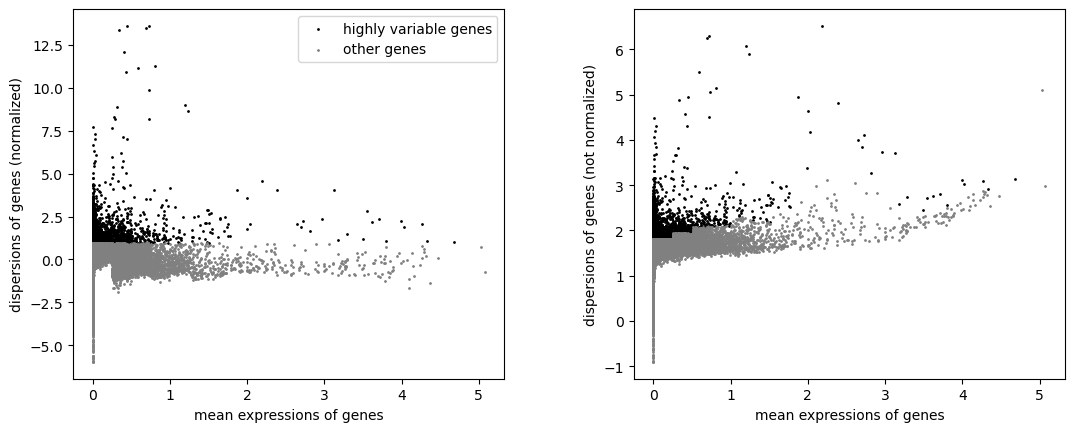

In [39]:
sc.pp.normalize_total(adata_ref,target_sum=1e4)
sc.pp.log1p(adata_ref)
#特征选择，寻找高变基因 ，某些细胞中表达强烈，具有显著差异
sc.pp.highly_variable_genes(adata_ref, n_top_genes=2500)#min_mean=0.0125, max_mean=3, min_disp=0.5，top_gene介于2000~3000
# 绘制特异性基因散点图
sc.pl.highly_variable_genes(adata_ref)
#plt.show(block=True)
#保存刚刚处理完成的数据
adata_ref.raw = adata_ref
adata_ref = adata_ref[:,adata_ref.var.highly_variable]#添加新的列

In [42]:
adata_ref

AnnData object with n_obs × n_vars = 30000 × 2500
    obs: 'library', 'sample', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_ncRNA', 'pct_counts_ncRNA', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'celltype_l1', 'celltype_l2', 'celltype_l3', 'celltype_l4', 'SEACell_ID', 'SEACell_l3', 'SEACell_l4', 'final_annotation', 'leiden_r0.5_n2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'pca', 'neighbors', 'umap', 'celltype_l1_colors', 'leiden_r0.5_n2', 'leiden_r0.5_n2_colors', 'sample_colors', 'final_annotation_colors', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

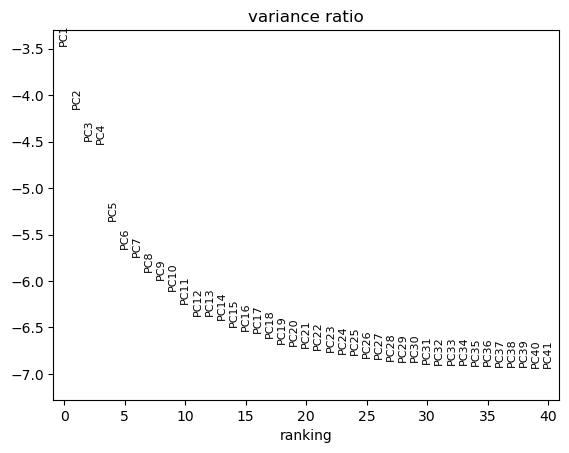

In [43]:
#数据归一化 STEP04
sc.pp.regress_out(adata_ref,['n_genes_by_counts','pct_counts_mt'])#回避不需要的变异来源,#归一化，每个标准化后的值减去该基因在所有细胞中的均值再除以该基因的标准差 value=  （exp-mean）/sd
#线性转换，PCA前步骤
sc.pp.scale(adata_ref,max_value=10)
#数据降维 主成分分析
# 绘制 PCA 图
sc.tl.pca(adata_ref,svd_solver='arpack')
#sc.pl.pca(adata, color='CST3')
#plt.show(block=True)
#pc图
sc.pl.pca_variance_ratio(adata_ref, n_pcs=40,log=True)
#plt.show(block=True)
#

In [44]:
sc.external.pp.harmony_integrate(adata_ref, key='library', max_iter_harmony=30)#去批次

2025-09-19 10:35:10,597 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-09-19 10:35:16,551 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-09-19 10:35:17,975 - harmonypy - INFO - Iteration 1 of 30
2025-09-19 10:44:39,636 - harmonypy - INFO - Iteration 2 of 30
2025-09-19 10:53:37,995 - harmonypy - INFO - Iteration 3 of 30
2025-09-19 11:02:03,777 - harmonypy - INFO - Iteration 4 of 30
2025-09-19 11:09:34,997 - harmonypy - INFO - Iteration 5 of 30
2025-09-19 11:17:11,583 - harmonypy - INFO - Iteration 6 of 30
2025-09-19 11:24:28,930 - harmonypy - INFO - Iteration 7 of 30
2025-09-19 11:31:35,991 - harmonypy - INFO - Iteration 8 of 30
2025-09-19 11:39:04,706 - harmonypy - INFO - Iteration 9 of 30
2025-09-19 11:46:30,213 - harmonypy - INFO - Iteration 10 of 30
2025-09-19 11:53:45,613 - harmonypy - INFO - Iteration 11 of 30
2025-09-19 12:01:08,843 - harmonypy - INFO - Iteration 12 of 30
2025-09-19 12:08:31,787 - harmonypy - INFO - Iteration 13 of

In [45]:
sc.pp.neighbors(adata_ref)
sc.tl.umap(adata_ref)

In [46]:
sc.tl.leiden(adata_ref,n_iterations=2,resolution=0.5,key_added='leiden_r0.5_n2')#划分群

In [26]:
adata_ref.obs['celltype_l1'].value_counts()

celltype_l1
CD4_T               10761
CD8_T                6247
unconvensional_T     4540
Myeloid              3554
B                    2553
NK&ILC               2345
Name: count, dtype: int64

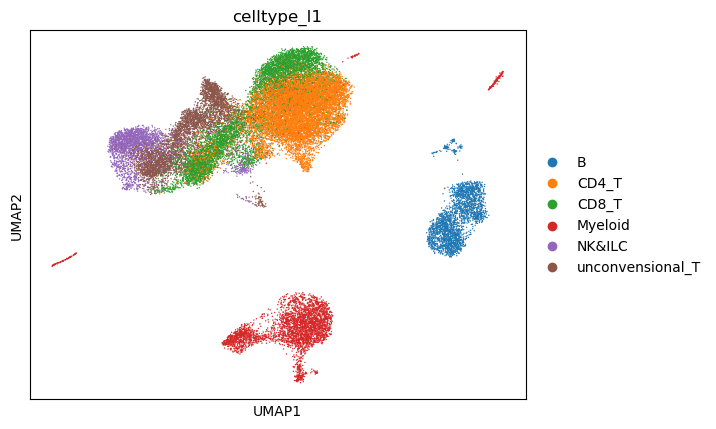

In [48]:
sc.pl.umap(adata_ref, color="celltype_l1")

In [89]:
adata_ref

AnnData object with n_obs × n_vars = 30000 × 2500
    obs: 'library', 'sample', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'total_counts_ncRNA', 'pct_counts_ncRNA', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'celltype_l1', 'celltype_l2', 'celltype_l3', 'celltype_l4', 'SEACell_ID', 'SEACell_l3', 'SEACell_l4', 'final_annotation', 'leiden_r0.5_n2'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'pca', 'neighbors', 'umap', 'celltype_l1_colors', 'leiden_r0.5_n2', 'sample_colors', 'final_annotation_colors', 'log1p', 'hvg'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [50]:
adata = adata_sub

In [51]:
var_names = adata_ref.var_names.intersection(adata.var_names)
adata_ref = adata_ref[:, var_names].copy()
adata = adata[:, var_names].copy()

In [52]:
adata

AnnData object with n_obs × n_vars = 532570 × 2500
    obs: 'sampleID', 'celltype', 'majorType', 'Patients', 'Age', 'Sex', 'CoVID-19 severity', 'Sample time'
    var: 'gene_ids', 'feature_types'

In [53]:
sc.tl.ingest(adata, adata_ref, obs="celltype_l1")

/media/AnalysisTempDisk/Caipengfei/miniconda3/envs/SnapATAC2/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
IOStream.flush timed out


In [54]:
adata.uns["celltype_l1_colors"] = adata_ref.uns["celltype_l1_colors"]  # fix colors

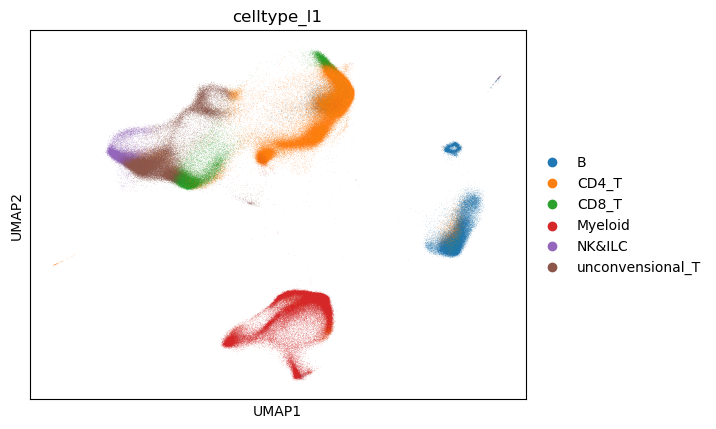

In [55]:
sc.pl.umap(adata, color=["celltype_l1"], wspace=0.5)

In [62]:
adata

AnnData object with n_obs × n_vars = 532570 × 2500
    obs: 'sampleID', 'celltype', 'majorType', 'Patients', 'Age', 'Sex', 'CoVID-19 severity', 'Sample time', 'celltype_l1'
    var: 'gene_ids', 'feature_types'
    uns: 'celltype_l1_colors', 'majorType_colors'
    obsm: 'rep', 'X_umap', 'X_pca'

In [69]:
adata.obs['celltype_l1'].value_counts()

celltype_l1
CD4_T               255142
Myeloid             106129
unconvensional_T     63496
B                    47739
CD8_T                43388
NK&ILC               16676
Name: count, dtype: int64

In [59]:
adata.obs['CoVID-19 severity'].value_counts()

CoVID-19 severity
severe/critical    235200
mild/moderate      170571
control            126799
Name: count, dtype: int64

In [64]:
adata.obs['Sample time'].value_counts()

Sample time
progression      262109
convalescence    143662
control          126799
Name: count, dtype: int64

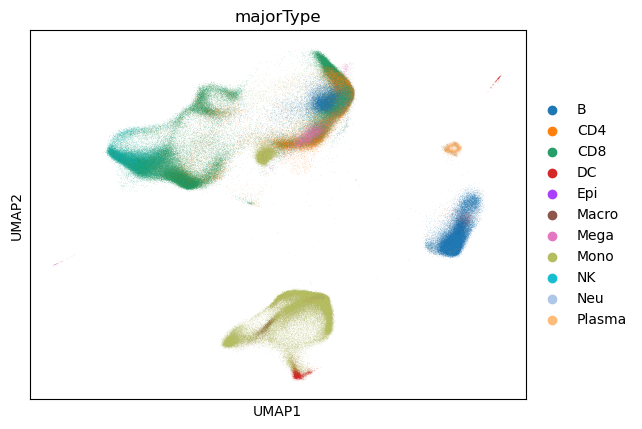

In [57]:
sc.pl.umap(adata, color=["majorType"], wspace=0.5)

In [66]:
adata.obs.groupby('Sample time')['Patients'].nunique()

/tmp/ipykernel_281240/865868046.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('Sample time')['Patients'].nunique()


Sample time
control          20
convalescence    24
progression      34
Name: Patients, dtype: int64

In [67]:
adata.obs['status'] = adata.obs['CoVID-19 severity'].astype(str) + '-' + adata.obs['Sample time'].astype(str)

In [68]:
adata.obs.groupby('status')['Patients'].nunique()

status
control-control                  20
mild/moderate-convalescence      11
mild/moderate-progression        13
severe/critical-convalescence    13
severe/critical-progression      21
Name: Patients, dtype: int64

In [75]:
adata_all = sc.read("./covid_scRNA.h5ad")

In [ ]:
# 合并细胞亚型
adata.obs['celltype_l1'] = adata.obs['celltype_l1'].replace({'unconvensional_T': 'CD8_T'})

In [76]:
adata_all.obs['celltype_l1'] = adata.obs.loc[adata_all.obs_names, 'celltype_l1'].values

In [77]:
adata_all.obs['celltype_l1'].unique()

['Myeloid', 'CD4_T', 'B', 'NK&ILC', 'CD8_T']
Categories (5, object): ['B', 'CD4_T', 'CD8_T', 'Myeloid', 'NK&ILC']

In [82]:
adata_all.obs['status'] = adata_all.obs['CoVID-19 severity'].astype(str) + '-' + adata_all.obs['Sample time'].astype(str)

In [83]:
import os
# 获取所有细胞类型
celltypes = adata_all.obs['celltype_l1'].unique()

# 创建输出目录
output_dir = './covid19_scRNA/'
os.makedirs(output_dir, exist_ok=True)

# 按细胞类型提取子集并保存
for ct in celltypes:
    adata_sub = adata_all[adata_all.obs['celltype_l1'] == ct].copy()
    out_path = os.path.join(output_dir, f"{ct}.h5ad")
    adata_sub.write(out_path)
    print(f"{ct} 已保存到 {out_path}")

Myeloid 已保存到 ./covid19_scRNA/Myeloid.h5ad
CD4_T 已保存到 ./covid19_scRNA/CD4_T.h5ad
B 已保存到 ./covid19_scRNA/B.h5ad
NK&ILC 已保存到 ./covid19_scRNA/NK&ILC.h5ad
CD8_T 已保存到 ./covid19_scRNA/CD8_T.h5ad


In [84]:
test = sc.read("./covid19_scRNA/B.h5ad")

In [85]:
test

AnnData object with n_obs × n_vars = 47739 × 27943
    obs: 'sampleID', 'celltype', 'majorType', 'Patients', 'Age', 'Sex', 'CoVID-19 severity', 'Sample time', 'celltype_l1', 'status'
    var: 'gene_ids', 'feature_types'

In [88]:
print(test.X)

  (2, 0)	1.0
  (3, 0)	1.0
  (4, 0)	1.0
  (8, 0)	1.0
  (11, 0)	1.0
  (16, 0)	1.0
  (17, 0)	1.0
  (34, 0)	2.0
  (37, 0)	1.0
  (39, 0)	1.0
  (41, 0)	2.0
  (44, 0)	2.0
  (45, 0)	2.0
  (46, 0)	1.0
  (51, 0)	1.0
  (61, 0)	5.0
  (81, 0)	2.0
  (82, 0)	1.0
  (84, 0)	1.0
  (94, 0)	1.0
  (103, 0)	1.0
  (105, 0)	1.0
  (106, 0)	1.0
  (114, 0)	1.0
  (117, 0)	1.0
  :	:
  (47566, 27942)	1.0
  (47570, 27942)	1.0
  (47571, 27942)	1.0
  (47574, 27942)	1.0
  (47590, 27942)	1.0
  (47594, 27942)	1.0
  (47603, 27942)	1.0
  (47604, 27942)	1.0
  (47615, 27942)	1.0
  (47619, 27942)	1.0
  (47625, 27942)	1.0
  (47631, 27942)	1.0
  (47634, 27942)	1.0
  (47639, 27942)	1.0
  (47643, 27942)	1.0
  (47645, 27942)	1.0
  (47654, 27942)	1.0
  (47667, 27942)	2.0
  (47682, 27942)	1.0
  (47690, 27942)	1.0
  (47699, 27942)	1.0
  (47704, 27942)	2.0
  (47711, 27942)	1.0
  (47726, 27942)	1.0
  (47728, 27942)	2.0


# ATAC

In [53]:
import scanpy as sc
import pandas as pd

In [54]:
adata = sc.read("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/public/output/covid_scATAC.h5ad")

In [55]:
adata

AnnData object with n_obs × n_vars = 133744 × 338003
    obs: 'orig.ident', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'scDblFinder.score', 'dataset', 'ATAC_snn_res.0.6', 'seurat_clusters'
    var: 'count', 'percentile'
    obsm: 'X_harmony', 'X_lsi', 'X_umap'

In [56]:
meta = pd.read_csv("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/public/output/covid_meta.csv",index_col=0)

In [57]:
meta

,orig.ident,nCount_ATAC,nFeature_ATAC,nucleosome_signal,nucleosome_percentile,TSS.enrichment,TSS.percentile,fragments,FRiP,blacklist_fraction,scDblFinder.class,scDblFinder.score,dataset,ATAC_snn_res.0.6,seurat_clusters,predicted.id.score,predicted.id
GSM8650243_108_AAACGAAAGCCCATTA-1,GSM8650243_108,5811,5085,0.388999,0.45,5.912065,0.29,10011,0.498052,0.008624,singlet,0.023005,GSM8650243_108,6,6,0.951075,CD8_T&unconvensional_T
GSM8650243_108_AAACGAAGTACAACGG-1,GSM8650243_108,3230,2897,0.421166,0.63,7.590212,0.83,5893,0.492279,0.009652,singlet,0.009516,GSM8650243_108,9,9,0.983598,CD4_T
GSM8650243_108_AAACGAATCGCAAGCC-1,GSM8650243_108,2971,2694,0.478320,0.84,8.396731,0.94,5218,0.506899,0.009830,singlet,0.023023,GSM8650243_108,9,9,0.951629,CD4_T
GSM8650243_108_AAACGAATCTCTGCGT-1,GSM8650243_108,3372,3070,0.317343,0.11,6.566249,0.52,5807,0.514896,0.006355,singlet,0.259914,GSM8650243_108,7,7,0.532796,CD8_T&unconvensional_T
GSM8650243_108_AAACTCGAGATGTTGA-1,GSM8650243_108,4619,4138,0.416971,0.61,7.570581,0.83,6839,0.595847,0.010552,singlet,0.201009,GSM8650243_108,6,6,0.737468,CD4_T
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM8650281_69_TTTGTGTCAAACAGTA-1,GSM8650281_69,2935,2763,0.852781,0.52,5.329805,0.27,5924,0.419480,0.009256,singlet,0.016692,GSM8650281_69,5,5,0.951941,Myeloid
GSM8650281_69_TTTGTGTCAAAGGAAG-1,GSM8650281_69,9029,7474,0.642610,0.05,6.916339,0.83,12393,0.681998,0.006507,singlet,0.260960,GSM8650281_69,10,10,1.000000,B
GSM8650281_69_TTTGTGTGTCCACCAG-1,GSM8650281_69,4413,4109,0.802752,0.40,6.258388,0.63,7013,0.538571,0.006884,singlet,0.027522,GSM8650281_69,5,5,1.000000,Myeloid
GSM8650281_69_TTTGTGTTCTATCTCA-1,GSM8650281_69,3033,2843,0.927107,0.66,5.576446,0.36,5856,0.455430,0.011624,singlet,0.248405,GSM8650281_69,6,6,0.968784,CD4_T


In [58]:
# 假设 meta 的 index 是细胞名，列是你要加到 obs 的信息
# 只保留 meta 中和 adata.obs_names 匹配的部分
meta_sub = meta.loc[adata.obs_names]

# 把 meta_sub 的每一列加到 adata.obs
for col in meta_sub.columns:
    adata.obs[col] = meta_sub[col].values

In [59]:
adata

AnnData object with n_obs × n_vars = 133744 × 338003
    obs: 'orig.ident', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'scDblFinder.score', 'dataset', 'ATAC_snn_res.0.6', 'seurat_clusters', 'scDblFinder.class', 'predicted.id.score', 'predicted.id'
    var: 'count', 'percentile'
    obsm: 'X_harmony', 'X_lsi', 'X_umap'

In [60]:
adata.obs['orig.ident'].unique()

array(['GSM8650243_108', 'GSM8650244_109', 'GSM8650245_110',
       'GSM8650246_111', 'GSM8650247_113', 'GSM8650248_114',
       'GSM8650249_115', 'GSM8650250_134', 'GSM8650251_144',
       'GSM8650252_147', 'GSM8650253_148', 'GSM8650254_151',
       'GSM8650255_165', 'GSM8650256_166', 'GSM8650257_167',
       'GSM8650258_170', 'GSM8650259_172', 'GSM8650260_207',
       'GSM8650261_208', 'GSM8650262_210', 'GSM8650263_212',
       'GSM8650264_215', 'GSM8650265_218', 'GSM8650266_245',
       'GSM8650267_413', 'GSM8650268_414', 'GSM8650269_415',
       'GSM8650270_416', 'GSM8650271_417', 'GSM8650272_418',
       'GSM8650273_419', 'GSM8650274_562', 'GSM8650275_563',
       'GSM8650276_564', 'GSM8650277_567', 'GSM8650278_574',
       'GSM8650279_67', 'GSM8650280_68', 'GSM8650281_69'], dtype=object)

In [61]:
import pandas as pd

In [62]:
meta_age = pd.read_excel("/media/AnalysisTempDisk/Caipengfei/workspace/cxy/public/output/covid_age.xlsx")

# 假设前两列为第0、1列，后两列为第2、3列
meta_age['sample'] = meta_age.iloc[:, 0].astype(str) + "_" + meta_age.iloc[:, 1].astype(str)
meta_age['status'] = meta_age.iloc[:, 2].astype(str) + "_" + meta_age.iloc[:, 3].astype(str)

In [63]:
meta_age.head()

,GSM,sample,covid_level,progress,Age,status
0,GSM8650279,GSM8650279_67,Mild/Moderate,Covid,64,Mild/Moderate_Covid
1,GSM8650280,GSM8650280_68,Mild/Moderate,Covid,30,Mild/Moderate_Covid
2,GSM8650281,GSM8650281_69,Mild/Moderate,Covid,75,Mild/Moderate_Covid
3,GSM8650243,GSM8650243_108,Reconvalescence,Rec,43,Reconvalescence_Rec
4,GSM8650244,GSM8650244_109,Healthy,Healthy,49,Healthy_Healthy


In [64]:
meta_age[meta_age['progress']=='Healthy']

,GSM,sample,covid_level,progress,Age,status
4,GSM8650244,GSM8650244_109,Healthy,Healthy,49,Healthy_Healthy
5,GSM8650245,GSM8650245_110,Healthy,Healthy,48,Healthy_Healthy
6,GSM8650246,GSM8650246_111,Healthy,Healthy,69,Healthy_Healthy
7,GSM8650247,GSM8650247_113,Healthy,Healthy,27,Healthy_Healthy
8,GSM8650248,GSM8650248_114,Healthy,Healthy,35,Healthy_Healthy
9,GSM8650249,GSM8650249_115,Healthy,Healthy,41,Healthy_Healthy
15,GSM8650255,GSM8650255_165,Healthy,Healthy,68,Healthy_Healthy
16,GSM8650256,GSM8650256_166,Healthy,Healthy,57,Healthy_Healthy
18,GSM8650258,GSM8650258_170,Healthy,Healthy,72,Healthy_Healthy
20,GSM8650260,GSM8650260_207,Healthy,Healthy,48,Healthy_Healthy


In [65]:
# 假设 meta_age['sample'] 是样本名，meta_age 其他列是要加的信息
# 先把 meta_age 设置索引为 sample
meta_age = meta_age.set_index('sample')

# 按样本名映射其他信息到 adata.obs
for col in meta_age.columns:
    adata.obs[col] = adata.obs['orig.ident'].map(meta_age[col])

In [66]:
len(adata.obs['GSM'].unique())

39

In [67]:
adata

AnnData object with n_obs × n_vars = 133744 × 338003
    obs: 'orig.ident', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'scDblFinder.score', 'dataset', 'ATAC_snn_res.0.6', 'seurat_clusters', 'scDblFinder.class', 'predicted.id.score', 'predicted.id', 'GSM', 'covid_level', 'progress', 'Age', 'status'
    var: 'count', 'percentile'
    obsm: 'X_harmony', 'X_lsi', 'X_umap'

In [68]:
import os
# 获取所有细胞类型
celltypes = adata.obs['predicted.id'].unique()

# 创建输出目录
output_dir = './processed_data/covid19_scATAC/'
os.makedirs(output_dir, exist_ok=True)

# 按细胞类型提取子集并保存
for ct in celltypes:
    adata_sub = adata[adata.obs['predicted.id'] == ct].copy()
    out_path = os.path.join(output_dir, f"{ct}.h5ad")
    adata_sub.write(out_path)
    print(f"{ct} 已保存到 {out_path}")

CD8_T&unconvensional_T 已保存到 ./processed_data/covid19_scATAC/CD8_T&unconvensional_T.h5ad
CD4_T 已保存到 ./processed_data/covid19_scATAC/CD4_T.h5ad
Myeloid 已保存到 ./processed_data/covid19_scATAC/Myeloid.h5ad
NK&ILC 已保存到 ./processed_data/covid19_scATAC/NK&ILC.h5ad
B 已保存到 ./processed_data/covid19_scATAC/B.h5ad


In [69]:
test = sc.read("./processed_data/covid19_scATAC/B.h5ad")

In [70]:
test

AnnData object with n_obs × n_vars = 12032 × 338003
    obs: 'orig.ident', 'nCount_ATAC', 'nFeature_ATAC', 'nucleosome_signal', 'nucleosome_percentile', 'TSS.enrichment', 'TSS.percentile', 'fragments', 'FRiP', 'blacklist_fraction', 'scDblFinder.score', 'dataset', 'ATAC_snn_res.0.6', 'seurat_clusters', 'scDblFinder.class', 'predicted.id.score', 'predicted.id', 'GSM', 'covid_level', 'progress', 'Age', 'status'
    var: 'count', 'percentile'
    obsm: 'X_harmony', 'X_lsi', 'X_umap'

In [71]:
print(test.X)

  (292, 0)	1.0
  (655, 0)	1.0
  (932, 0)	1.0
  (1089, 0)	1.0
  (2956, 0)	1.0
  (3286, 0)	1.0
  (3412, 0)	1.0
  (3992, 0)	1.0
  (4164, 0)	1.0
  (4459, 0)	1.0
  (4814, 0)	1.0
  (4948, 0)	1.0
  (5495, 0)	1.0
  (6134, 0)	1.0
  (6182, 0)	1.0
  (7579, 0)	1.0
  (8217, 0)	1.0
  (9614, 0)	1.0
  (10816, 0)	1.0
  (10837, 0)	1.0
  (11034, 0)	1.0
  (1389, 1)	1.0
  (6897, 1)	1.0
  (6941, 5)	1.0
  (10684, 5)	1.0
  :	:
  (9766, 338001)	1.0
  (9863, 338001)	1.0
  (9887, 338001)	1.0
  (9929, 338001)	1.0
  (10204, 338001)	1.0
  (11004, 338001)	1.0
  (11123, 338001)	1.0
  (11472, 338001)	1.0
  (11781, 338001)	1.0
  (12017, 338001)	1.0
  (1405, 338002)	1.0
  (1529, 338002)	1.0
  (1766, 338002)	1.0
  (1940, 338002)	1.0
  (1975, 338002)	1.0
  (2006, 338002)	1.0
  (4737, 338002)	1.0
  (6409, 338002)	1.0
  (7187, 338002)	1.0
  (7214, 338002)	1.0
  (8720, 338002)	1.0
  (8948, 338002)	1.0
  (9231, 338002)	1.0
  (10606, 338002)	1.0
  (11580, 338002)	1.0
